In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import os


def get_ncfiles(prefix, year_range = range(25,40)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h2.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

def get_ncfiles_col(prefix, year_range = range(25,40)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h1.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

In [2]:
colfiles_good = get_ncfiles_col('20240304_3')
nc_files_good = get_ncfiles('20240304_3')
colfiles_bad = get_ncfiles_col('20240304_6')
nc_files_bad  = get_ncfiles('20240304_6')

ds = xr.open_mfdataset(nc_files_good)
ds2 = xr.open_mfdataset(nc_files_bad)
hr = xr.open_mfdataset(colfiles_good)
hr2 = xr.open_mfdataset(colfiles_bad)

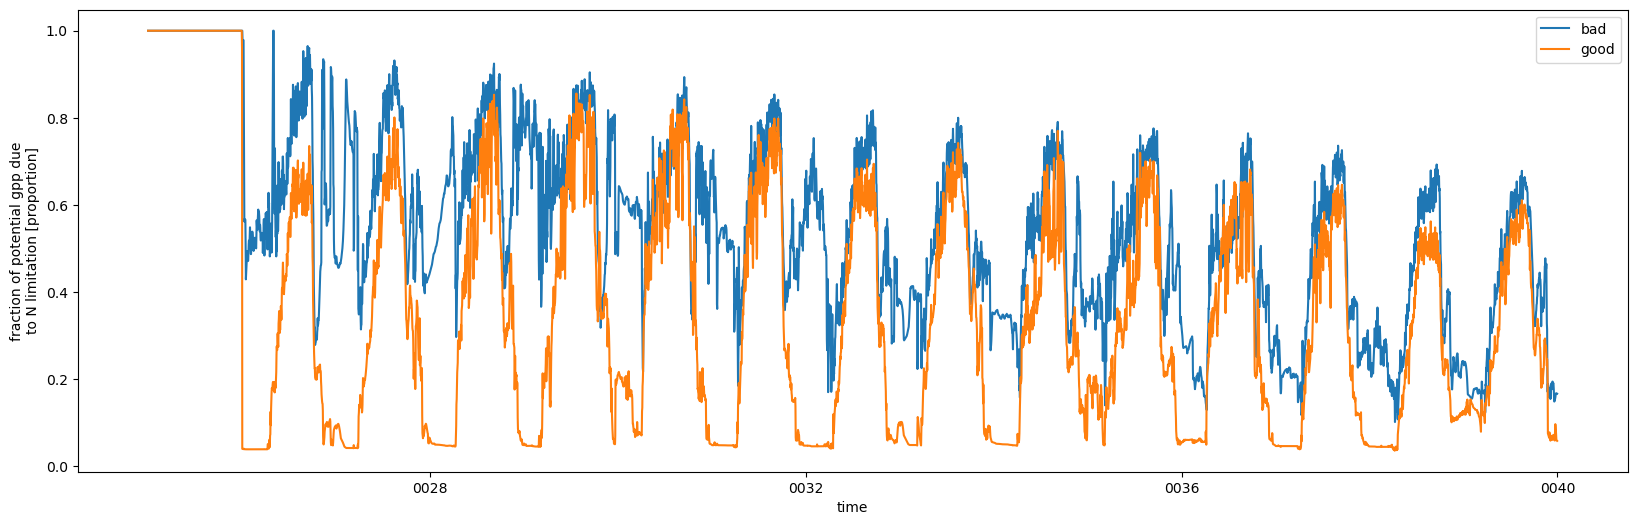

In [3]:
plt.figure(figsize = (20, 6))
hr2['FPG'][:, 0].plot(label = 'bad')
hr['FPG'][:, 0].plot(label = 'good')
plt.legend()

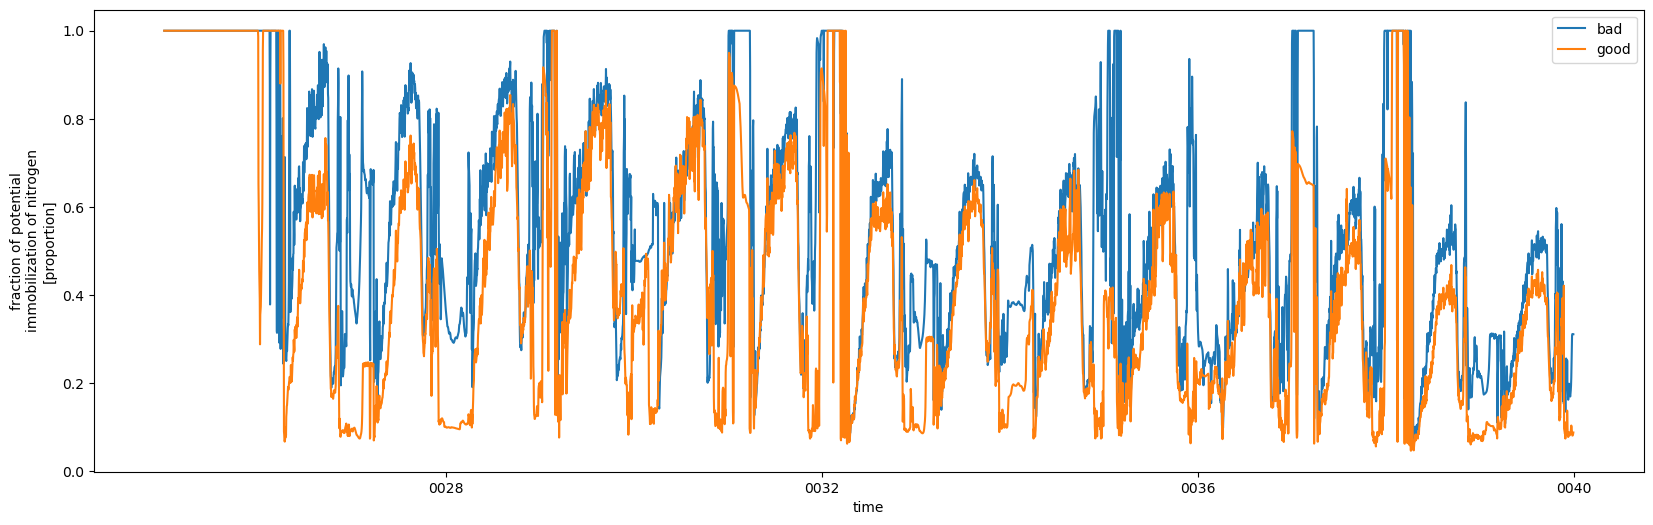

In [4]:
plt.figure(figsize = (20, 6))
hr2['FPI'][:, 0].plot(label = 'bad')
hr['FPI'][:, 0].plot(label = 'good')
plt.legend()

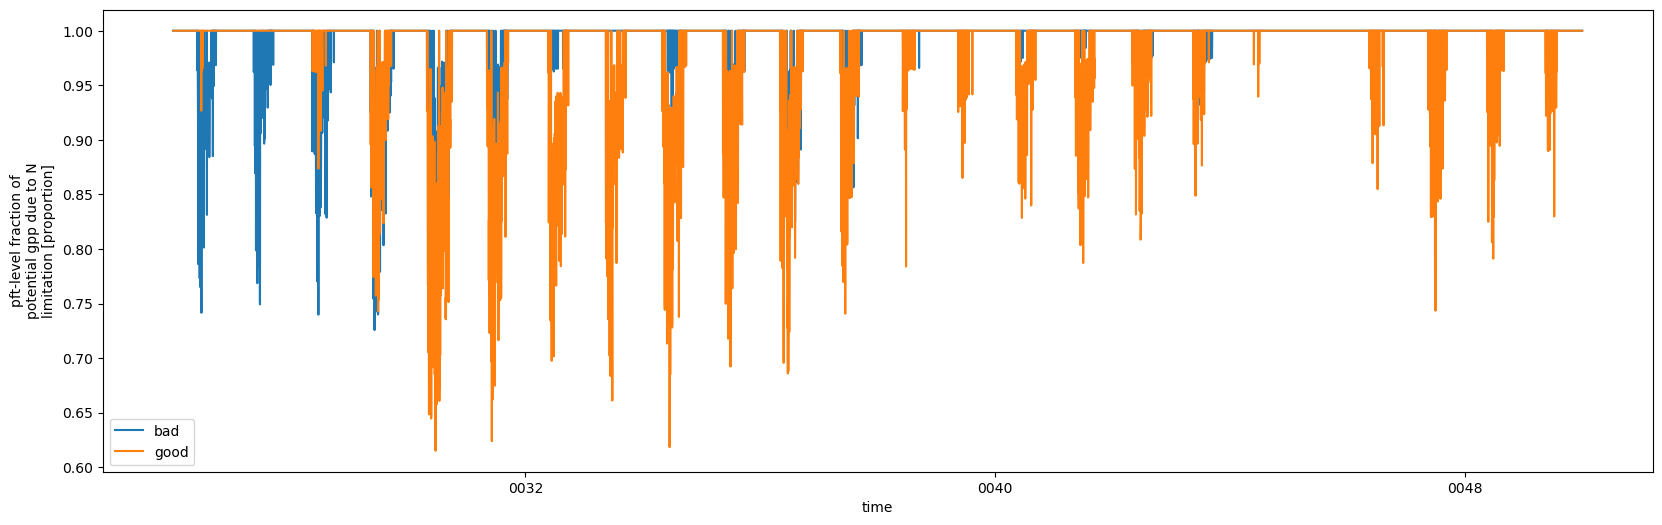

In [10]:
plt.figure(figsize = (20, 6))
ds2['FPG_PATCH'][:, 3].plot(label = 'bad')
ds['FPG_PATCH'][:, 3].plot(label = 'good')
plt.legend()

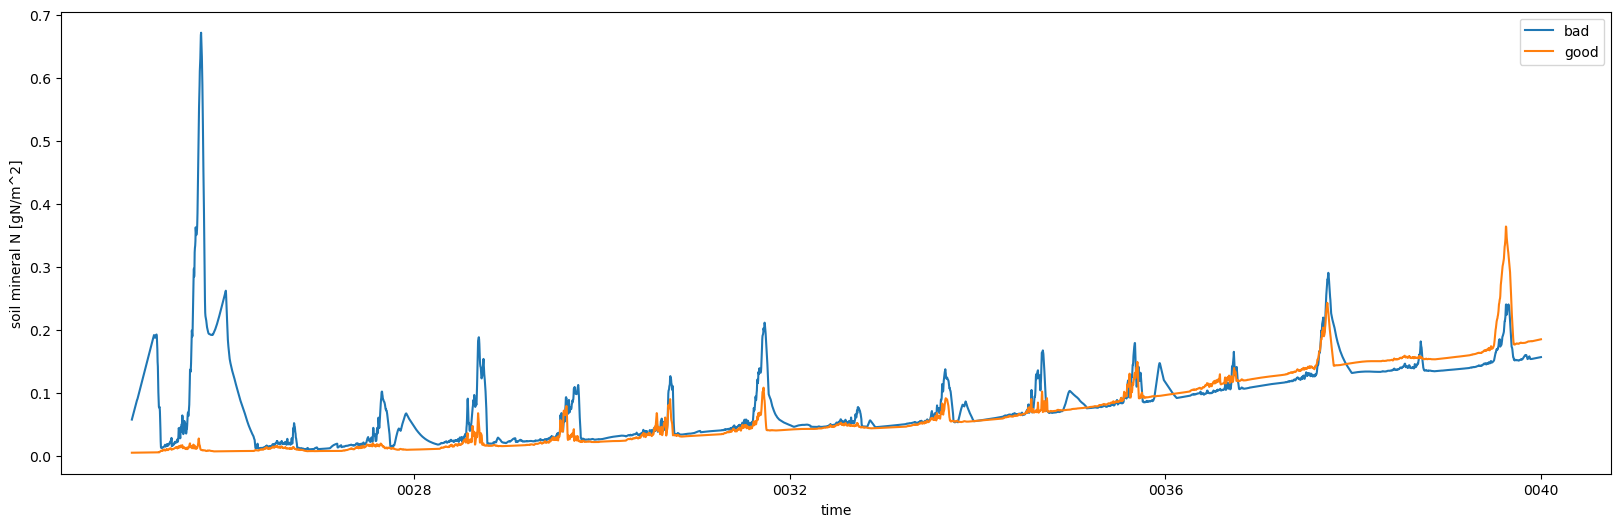

In [5]:
plt.figure(figsize = (20, 6))
hr2['SMINN'][:, 0].plot(label = 'bad')
hr['SMINN'][:, 0].plot(label = 'good')
plt.legend()

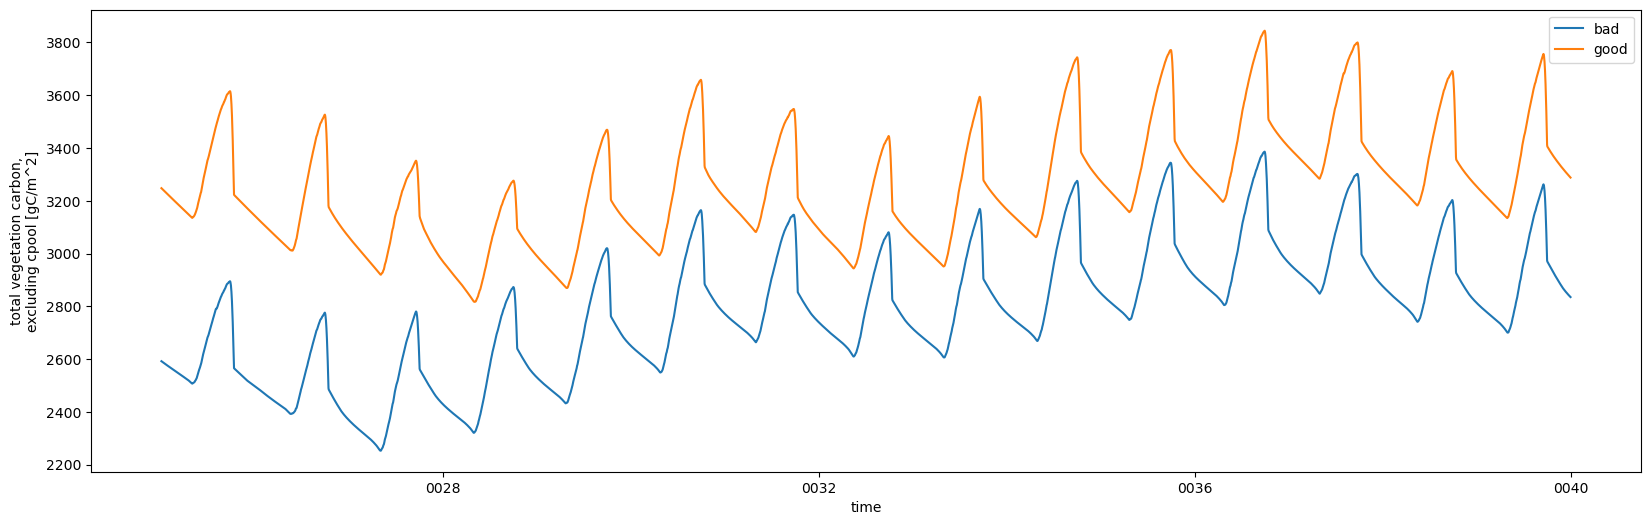

In [6]:
plt.figure(figsize = (20, 6))
ds2['TOTVEGC'][:, 3].plot(label = 'bad')
ds['TOTVEGC'][:, 3].plot(label = 'good')
plt.legend()

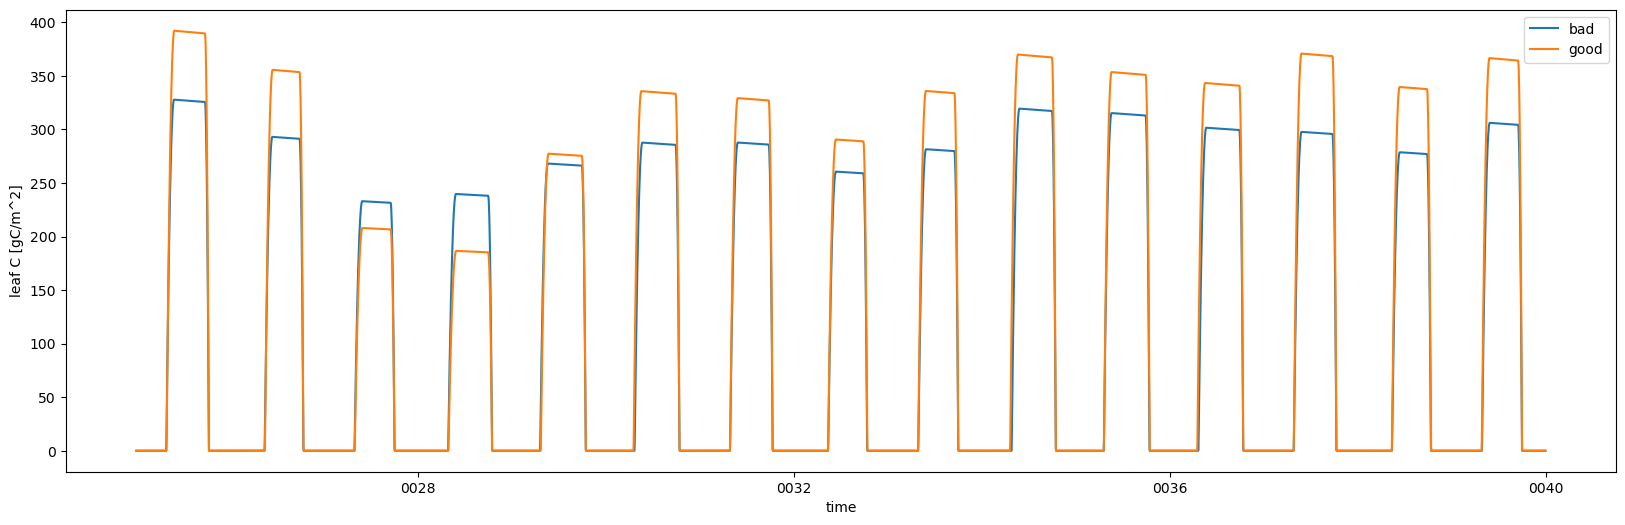

In [10]:
plt.figure(figsize = (20, 6))
ds2['LEAFC'][:, 3].plot(label = 'bad')
ds['LEAFC'][:, 3].plot(label = 'good')
plt.legend()

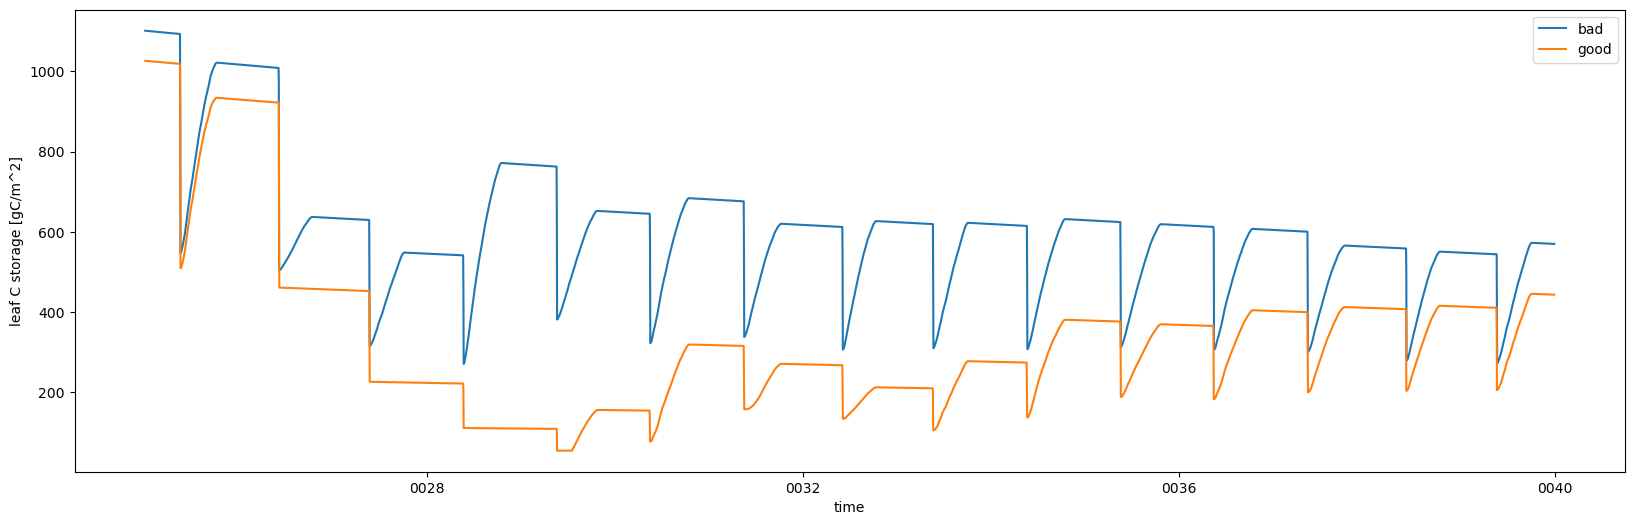

In [8]:
plt.figure(figsize = (20, 6))
ds2['LEAFC_STORAGE'][:, 11].plot(label = 'bad')
ds['LEAFC_STORAGE'][:, 11].plot(label = 'good')
plt.legend()

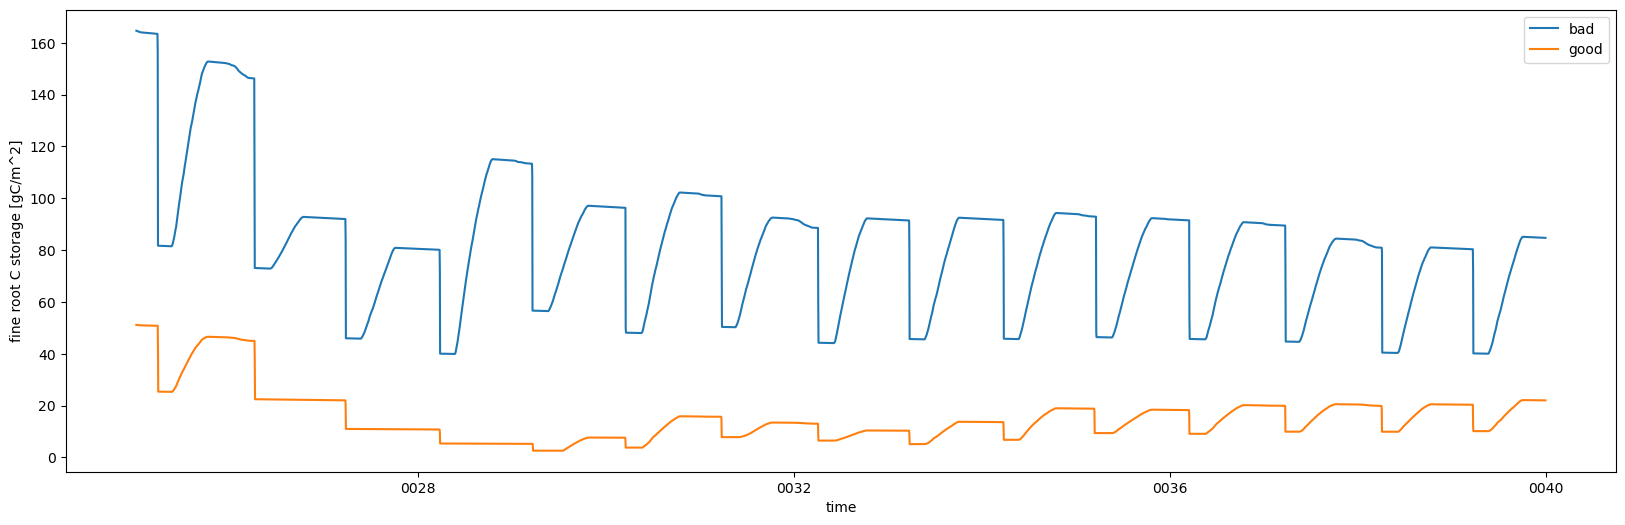

In [9]:
plt.figure(figsize = (20, 6))
ds2['FROOTC_STORAGE'][:, 11].plot(label = 'bad')
ds['FROOTC_STORAGE'][:, 11].plot(label = 'good')
plt.legend()

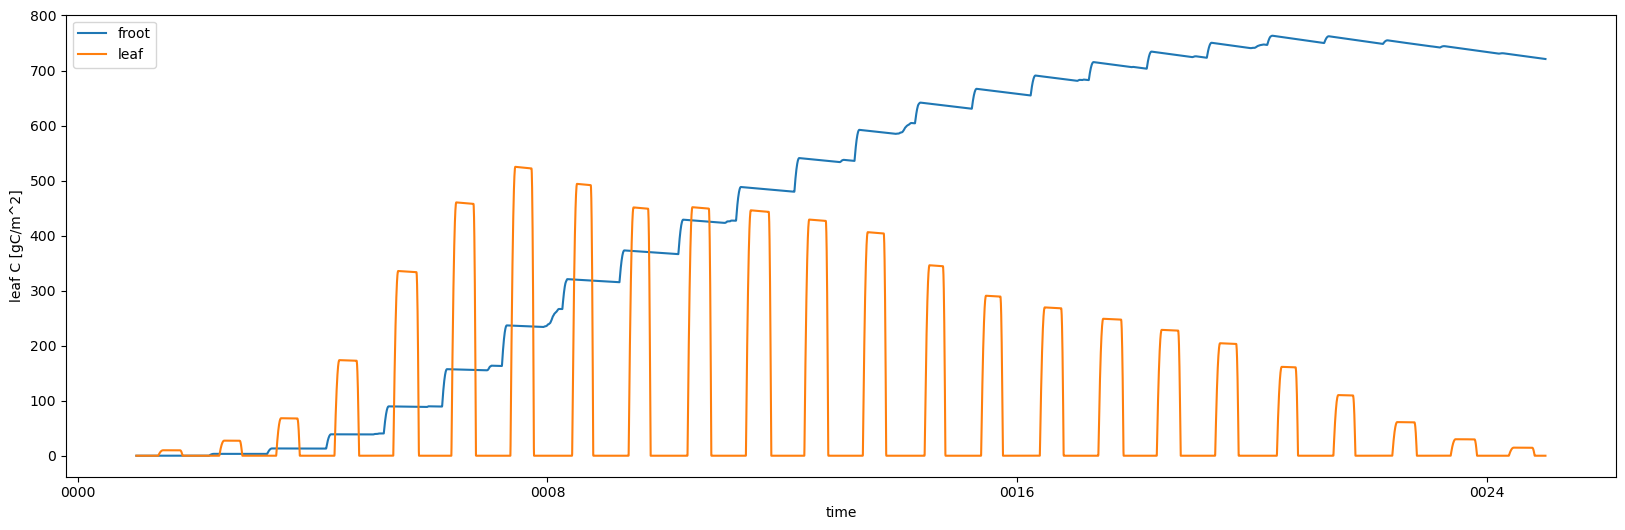

In [12]:
plt.figure(figsize = (20, 6))
ds2['FROOTC'][:, 11].plot(label = 'froot')
ds2['LEAFC'][:, 11].plot(label = 'leaf')
plt.legend()

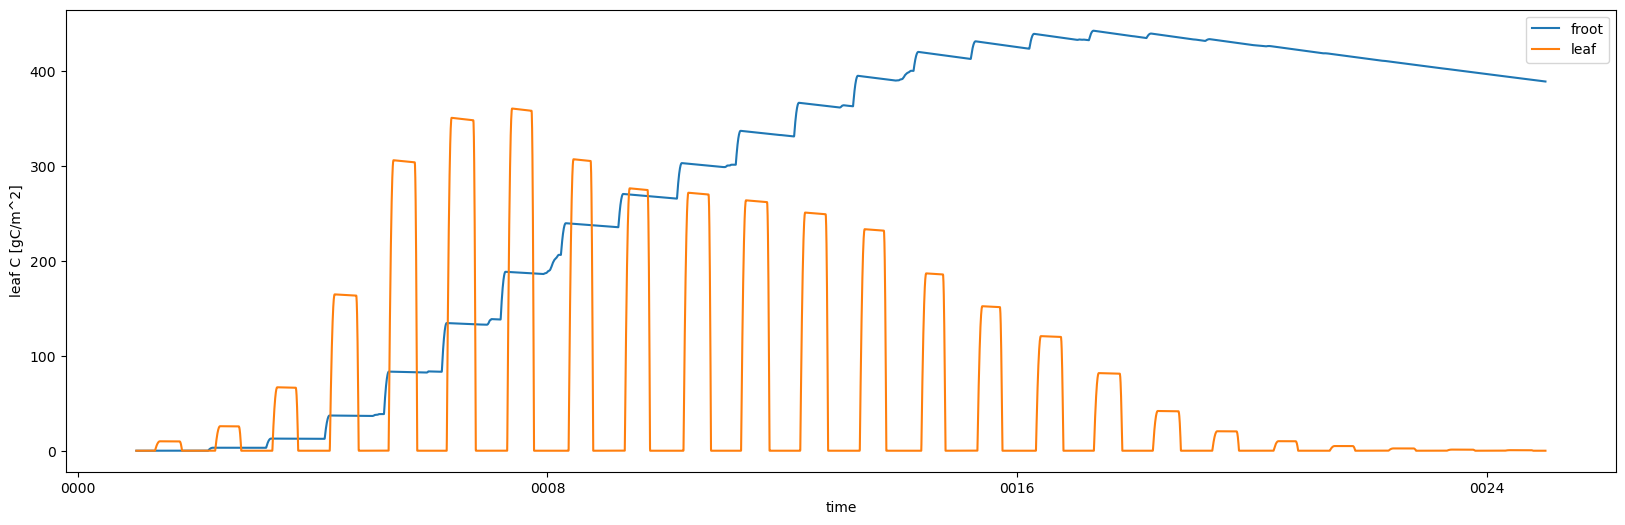

In [11]:
plt.figure(figsize = (20, 6))
ds2['FROOTC'][:, 3].plot(label = 'froot')
ds2['LEAFC'][:, 3].plot(label = 'leaf')
plt.legend()

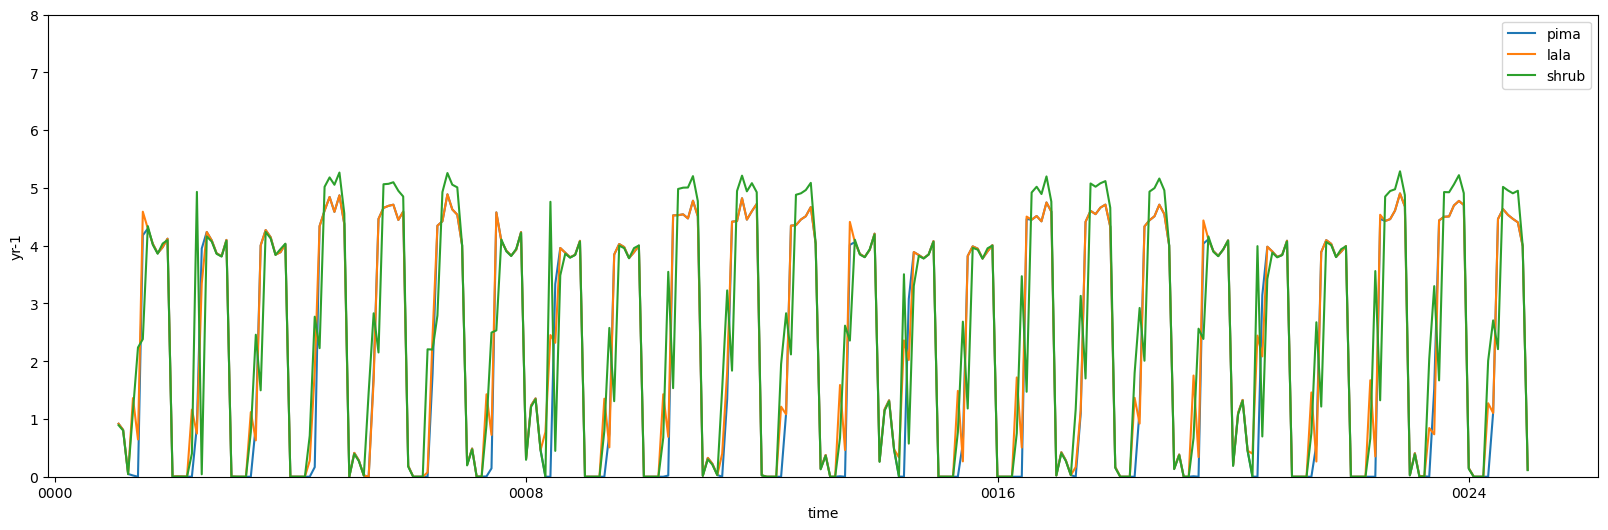

In [5]:
plt.figure(figsize = (20, 6))
(ds2['BGLFR_FROOT'][:, 2] * 365 * 86400).resample(time = '1M').mean().plot(label = 'pima')
(ds2['BGLFR_FROOT'][:, 3] * 365 * 86400).resample(time = '1M').mean().plot(label = 'lala')
(ds2['BGLFR_FROOT'][:, 11] * 365 * 86400).resample(time = '1M').mean().plot(label = 'shrub')
plt.ylabel('yr-1')
plt.ylim([0, 8])
plt.legend()

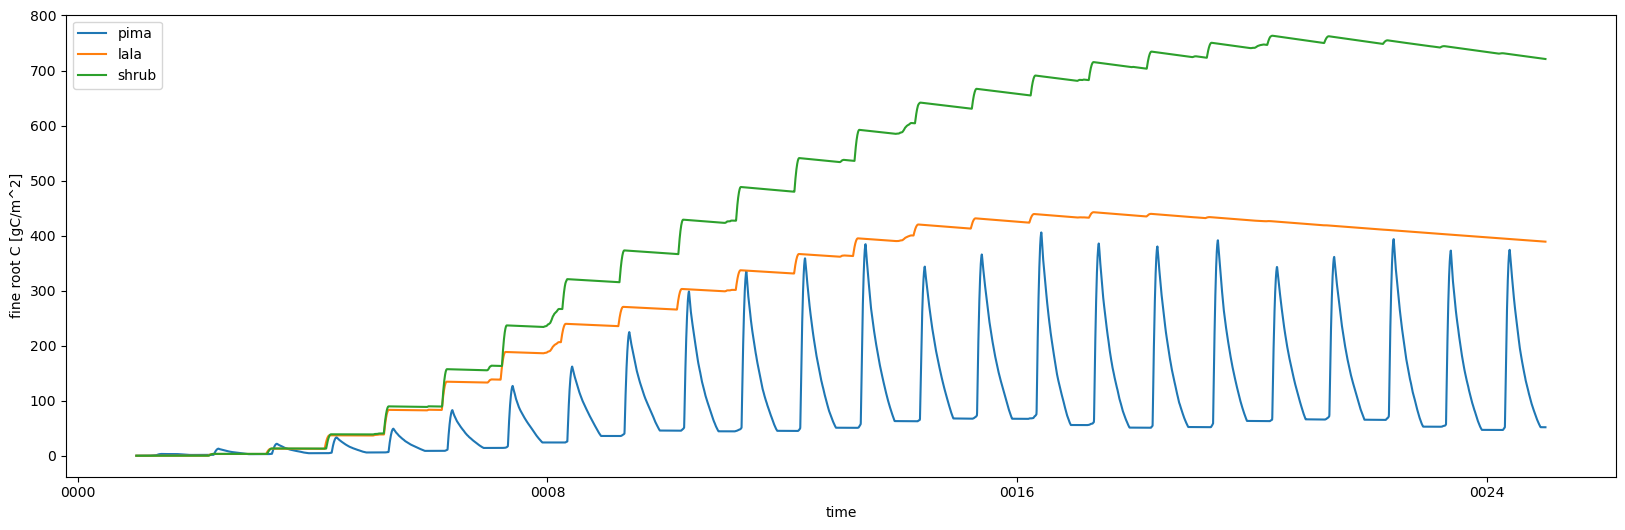

In [9]:
plt.figure(figsize = (20, 6))
ds2['FROOTC'][:, 2].plot(label = 'pima')
ds2['FROOTC'][:, 3].plot(label = 'lala')
ds2['FROOTC'][:, 11].plot(label = 'shrub')
plt.legend()

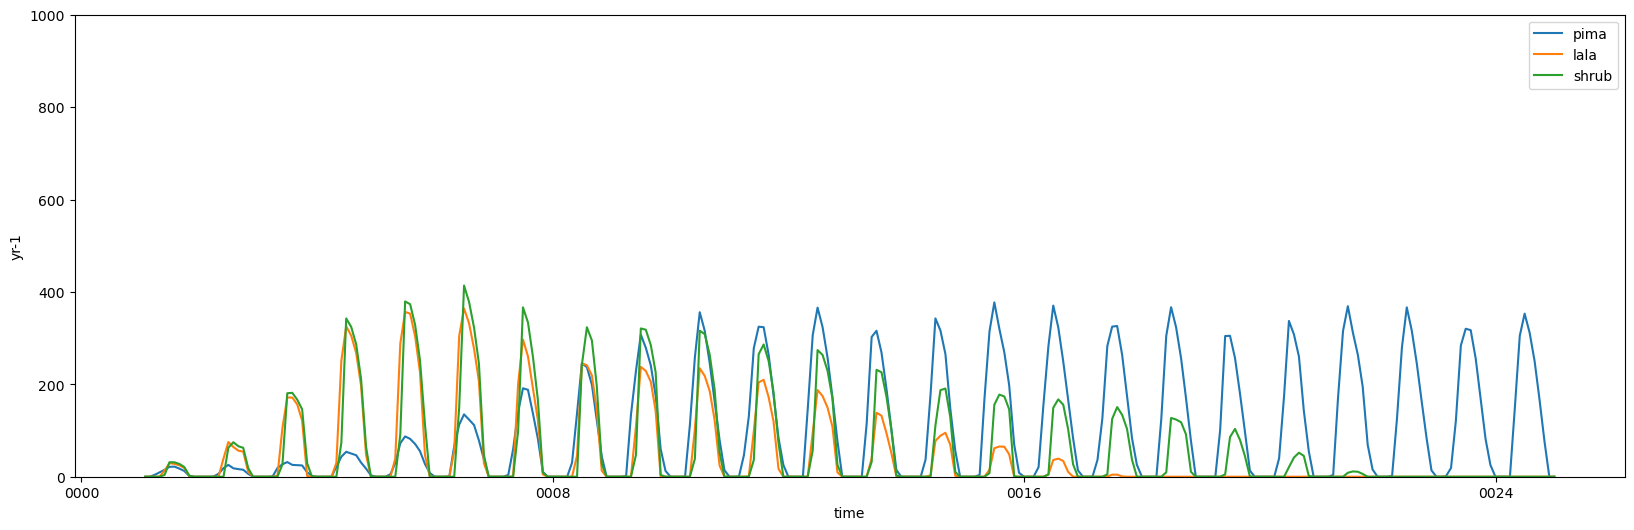

In [4]:
plt.figure(figsize = (20, 6))
((ds2['AR'] - ds2['MR'])[:, 2] * 365 * 86400).resample(time = '1M').mean().plot(label = 'pima')
((ds2['AR'] - ds2['MR'])[:, 3] * 365 * 86400).resample(time = '1M').mean().plot(label = 'lala')
((ds2['AR'] - ds2['MR'])[:, 11] * 365 * 86400).resample(time = '1M').mean().plot(label = 'shrub')
plt.ylabel('yr-1')
plt.ylim([0, 1000])
plt.legend()

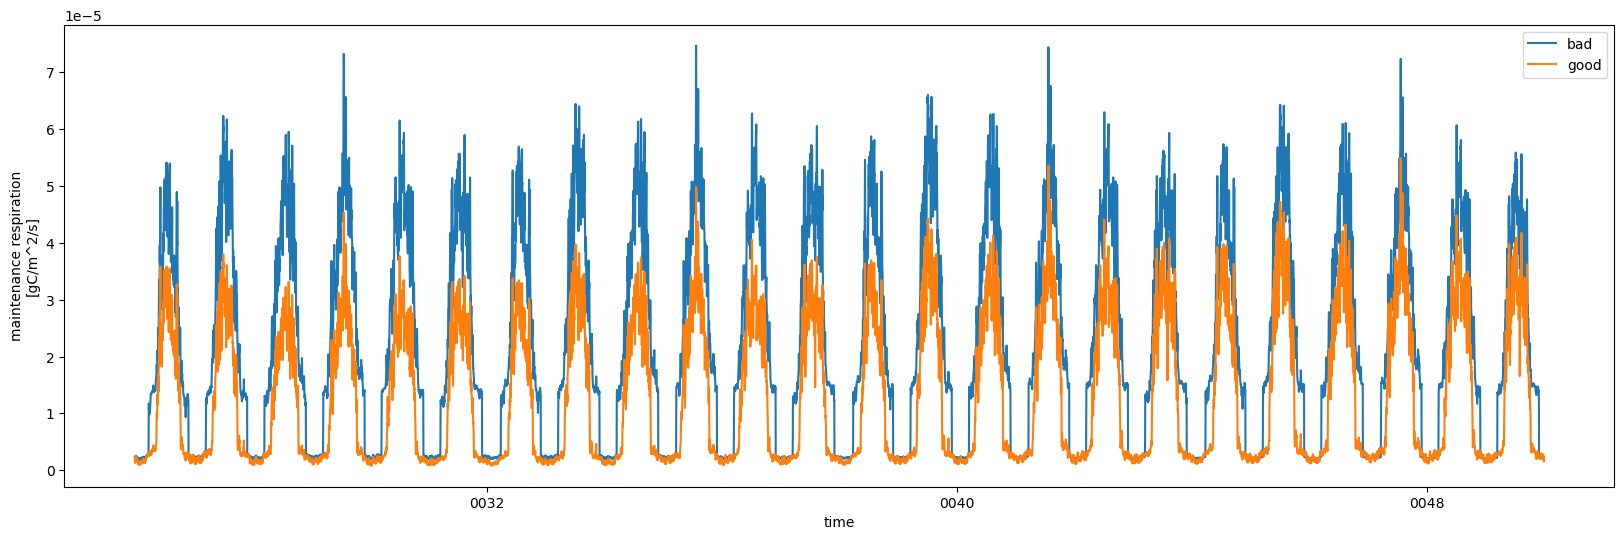

In [15]:
plt.figure(figsize = (20, 6))
ds2['MR'][:, 3].plot(label = 'bad')
ds['MR'][:, 3].plot(label = 'good')
plt.legend()

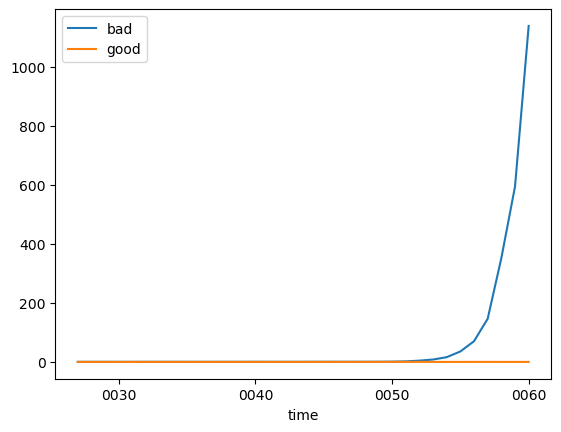

In [4]:
(ds2['MR'][:, 3].resample(time = '1Y').mean() / ds2['GPP'][:, 3].resample(time = '1Y').mean()).plot(label = 'bad')
(ds['MR'][:, 3].resample(time = '1Y').mean() / ds['GPP'][:, 3].resample(time = '1Y').mean()).plot(label = 'good')
plt.legend()

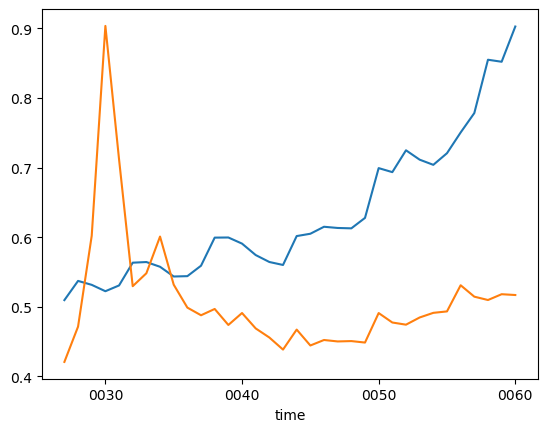

In [3]:
(ds2['MR'][:, 11].resample(time = '1Y').    mean() / ds2['GPP'][:, 11].resample(time = '1Y').mean()).plot(label = 'bad')
(ds['MR'][:, 11].resample(time = '1Y').mean() / ds['GPP'][:, 11].resample(time = '1Y').mean()).plot(label = 'good')

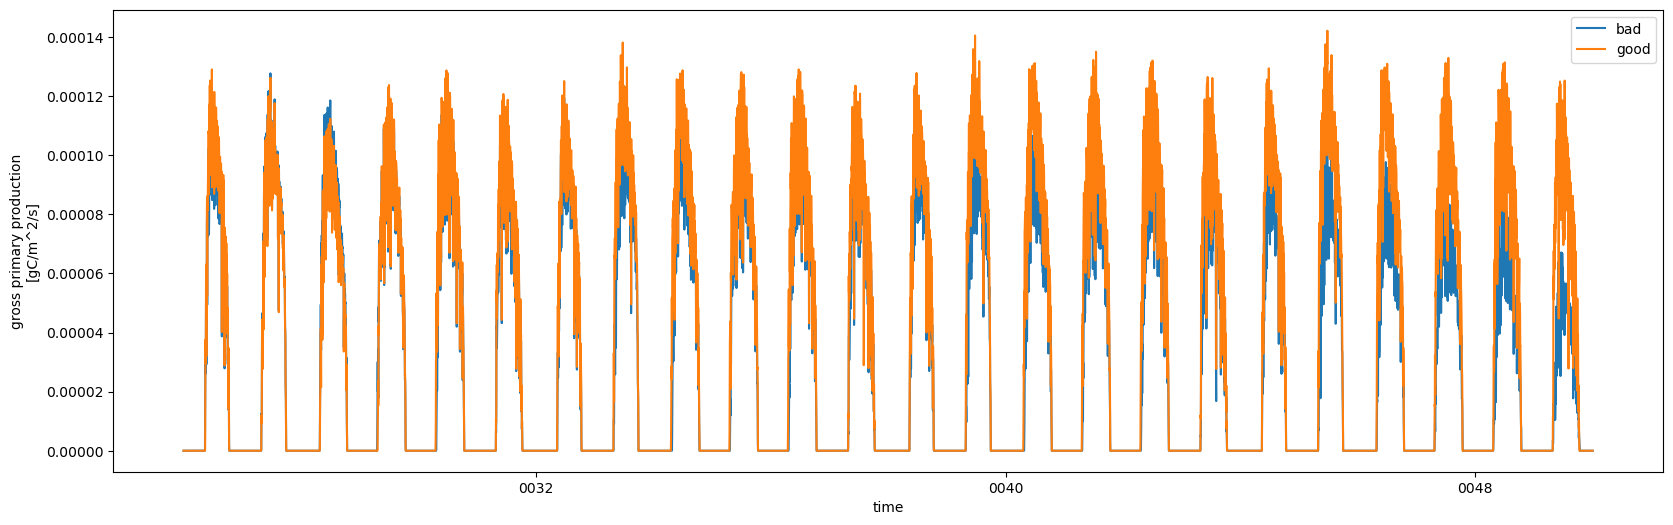

In [17]:

plt.figure(figsize = (20, 6))
ds2['GPP'][:, 3].plot(label = 'bad')
ds['GPP'][:, 3].plot(label = 'good')
plt.legend()

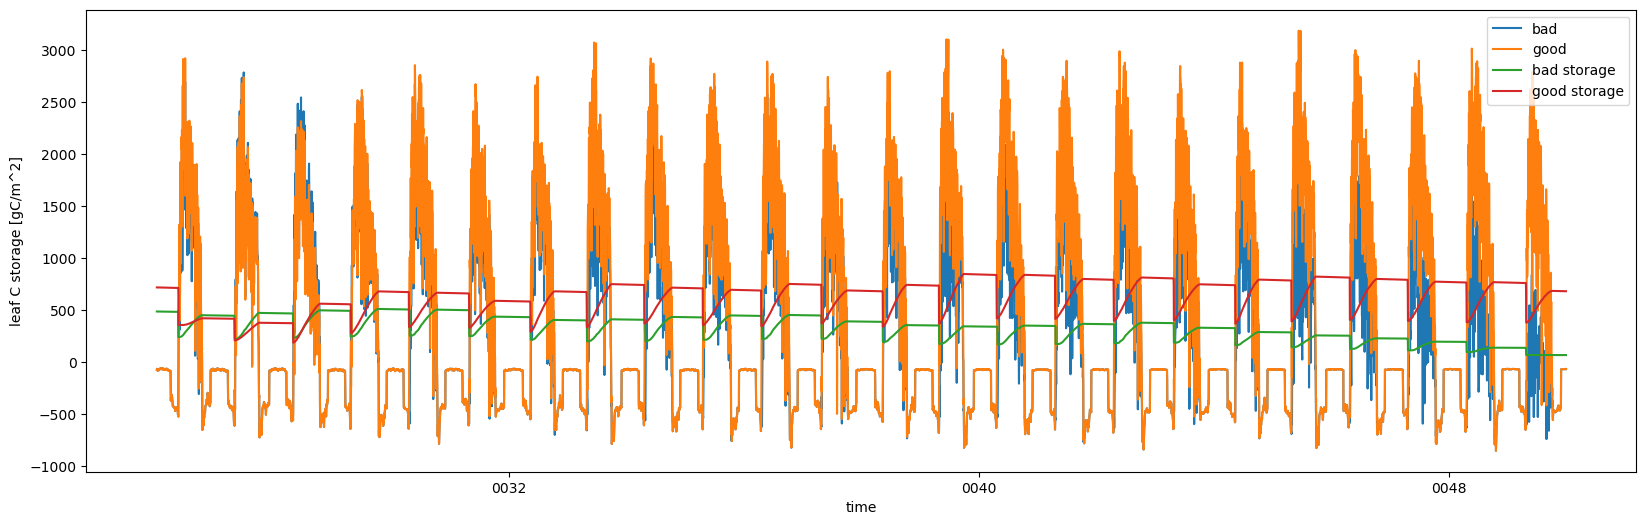

In [19]:
plt.figure(figsize = (20, 6))
((ds2['GPP'][:, 3] - ds2['MR'][:,3]) * 365 * 86400).plot(label = 'bad')
((ds['GPP'][:, 3] - ds2['MR'][:,3]) * 365 * 86400).plot(label = 'good')
ds2['LEAFC_STORAGE'][:, 3].plot(label = 'bad storage')
ds['LEAFC_STORAGE'][:, 3].plot(label = 'good storage')
#ds2['ONSET_FLAG'][:, 11].plot(label = 'bad onset')
#ds['ONSET_FLAG'][:, 11].plot(label = 'good onset')
plt.legend()

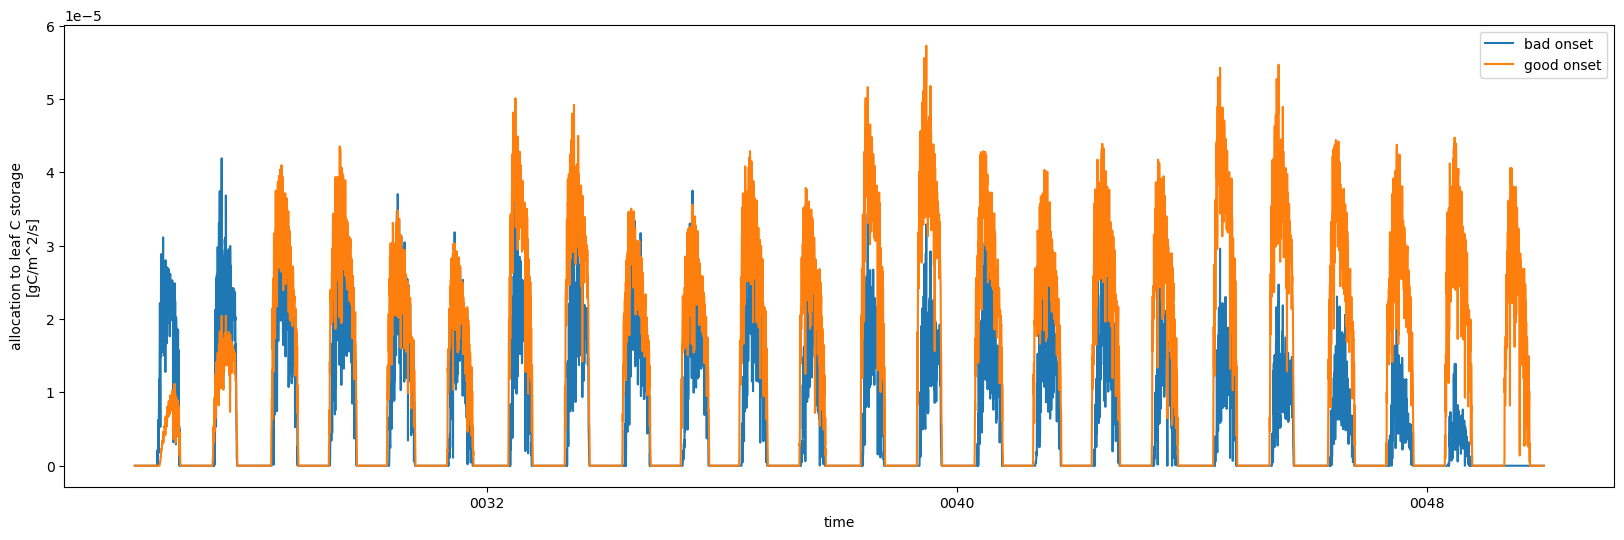

In [21]:
plt.figure(figsize = (20, 6))
ds2['CPOOL_TO_LEAFC_STORAGE'][:, 3].plot(label = 'bad onset')
ds['CPOOL_TO_LEAFC_STORAGE'][:, 3].plot(label = 'good onset')
plt.legend()

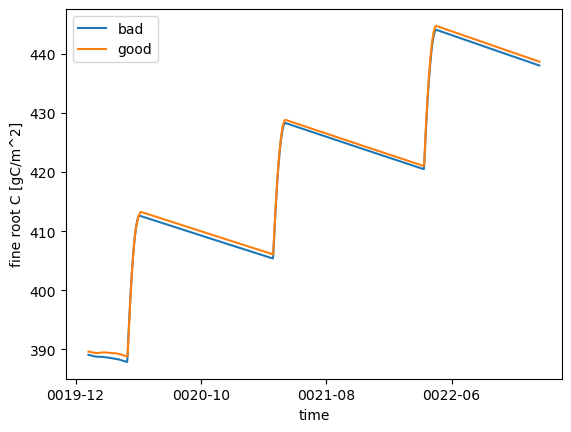

In [25]:
ds3 = xr.open_mfdataset(get_ncfiles('20240304_3', range(20,23)))
ds4 = xr.open_mfdataset(get_ncfiles('20240304_4', range(20,23)))
ds4['FROOTC'][:, 11].plot(label = 'bad')
ds3['FROOTC'][:, 11].plot(label = 'good')
plt.legend()
ds3.close()
ds4.close()

KeyError: 'CPOOL'

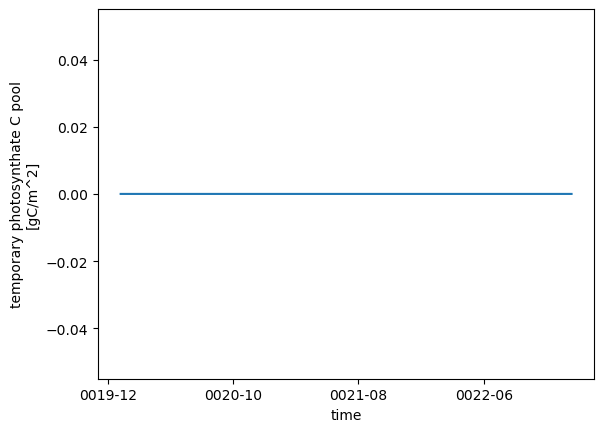

In [5]:
ds3 = xr.open_mfdataset(get_ncfiles('20240304_3', range(20,23)))
ds4 = xr.open_mfdataset(get_ncfiles('20240304_5', range(20,23)))
ds4['CPOOL'][:, 11].plot(label = 'bad')
ds3['CPOOL'][:, 11].plot(label = 'good')
plt.legend()
ds3.close()
ds4.close()

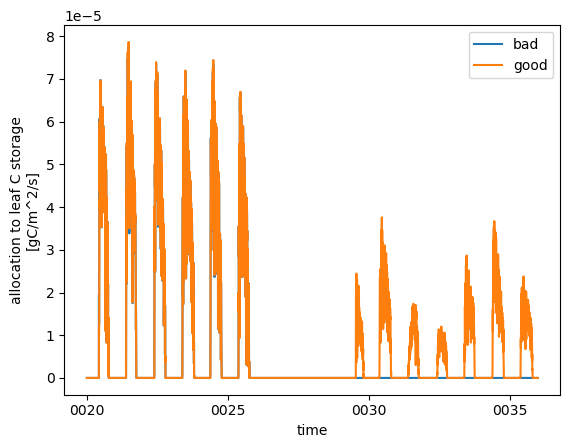

In [5]:
ds3 = xr.open_mfdataset(get_ncfiles('20240304_3', range(20,36)))
ds4 = xr.open_mfdataset(get_ncfiles('20240304_4', range(20,36)))
ds4['CPOOL_TO_LEAFC_STORAGE'][:, 11].plot(label = 'bad')
ds3['CPOOL_TO_LEAFC_STORAGE'][:, 11].plot(label = 'good')
plt.legend()
ds3.close()
ds4.close()

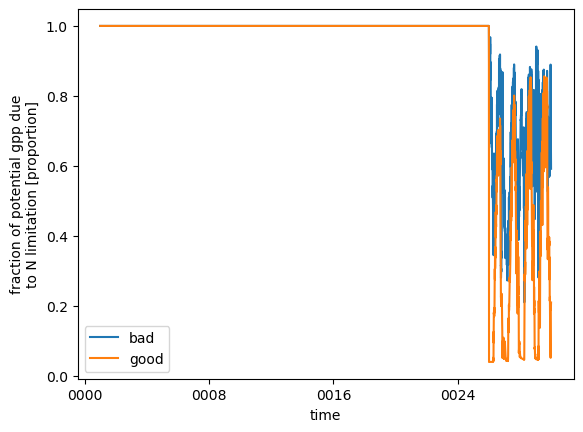

In [10]:
hr3 = xr.open_mfdataset(get_ncfiles_col('20240304_3', range(30)))
hr4 = xr.open_mfdataset(get_ncfiles_col('20240304_4', range(30)))
hr4['FPG'][:, 0].plot(label = 'bad')
hr3['FPG'][:, 0].plot(label = 'good')
plt.legend()
ds3.close()
ds4.close()

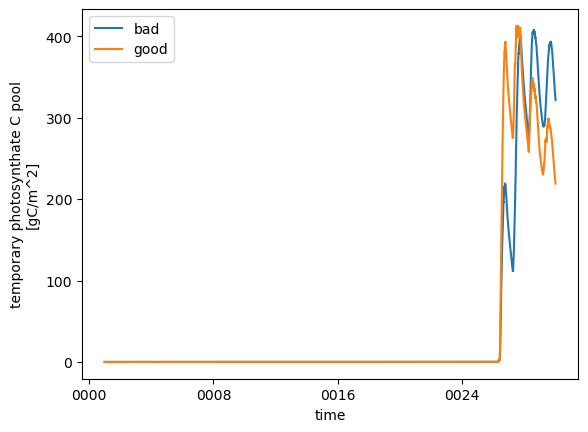

In [25]:
hr3 = xr.open_mfdataset(get_ncfiles_col('20240304_3', range(30)))
hr4 = xr.open_mfdataset(get_ncfiles_col('20240304_5', range(30)))
hr4['CPOOL'][:, 0].plot(label = 'bad')
hr3['CPOOL'][:, 0].plot(label = 'good')
plt.legend()
hr3.close()
hr4.close()

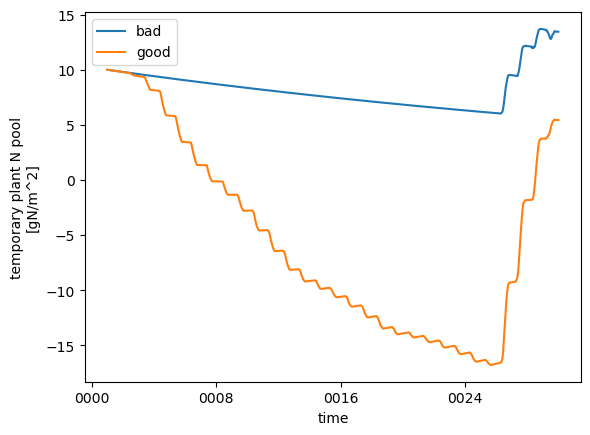

In [23]:
hr3 = xr.open_mfdataset(get_ncfiles_col('20240304_3', range(30)))
hr4 = xr.open_mfdataset(get_ncfiles_col('20240304_6', range(30)))
hr4['NPOOL'][:, 0].plot(label = 'bad')
hr3['NPOOL'][:, 0].plot(label = 'good')
plt.legend()
hr3.close()
hr4.close()

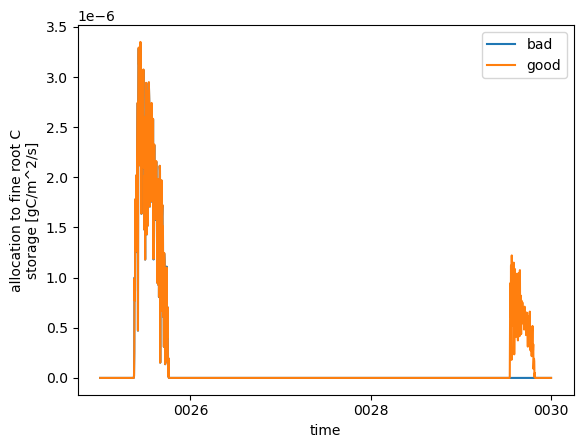

In [4]:
ds3 = xr.open_mfdataset(get_ncfiles('20240304_3', range(25,30)))
ds4 = xr.open_mfdataset(get_ncfiles('20240304_4', range(25,30)))
ds4['CPOOL_TO_FROOTC_STORAGE'][:, 11].plot(label = 'bad')
ds3['CPOOL_TO_FROOTC_STORAGE'][:, 11].plot(label = 'good')
plt.legend()
ds3.close()
ds4.close()

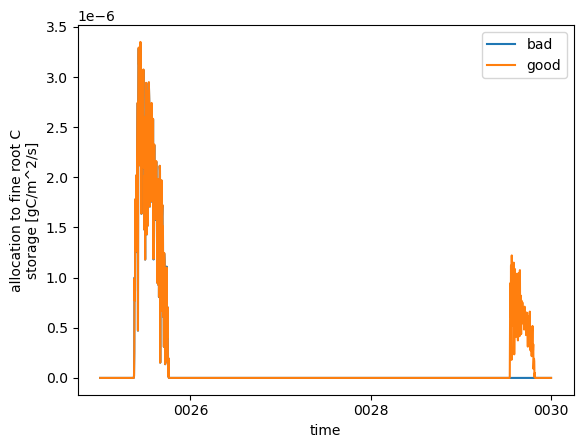

In [11]:
ds3 = xr.open_mfdataset(get_ncfiles('20240304_3', range(25,30)))
ds4 = xr.open_mfdataset(get_ncfiles('20240304_5', range(25,30)))
ds4['CPOOL_TO_FROOTC_STORAGE'][:, 11].plot(label = 'bad')
ds3['CPOOL_TO_FROOTC_STORAGE'][:, 11].plot(label = 'good')
plt.legend()
ds3.close()
ds4.close()

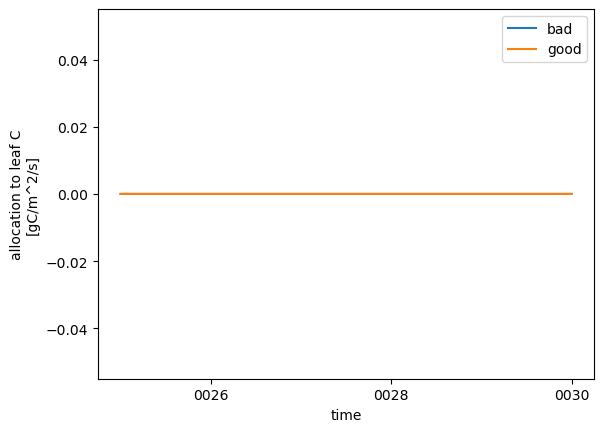

In [7]:
ds3 = xr.open_mfdataset(get_ncfiles('20240304_3', range(25,30)))
ds4 = xr.open_mfdataset(get_ncfiles('20240304_4', range(25,30)))
ds4['CPOOL_TO_LEAFC'][:, 11].plot(label = 'bad')
ds3['CPOOL_TO_LEAFC'][:, 11].plot(label = 'good')
plt.legend()
ds3.close()
ds4.close()

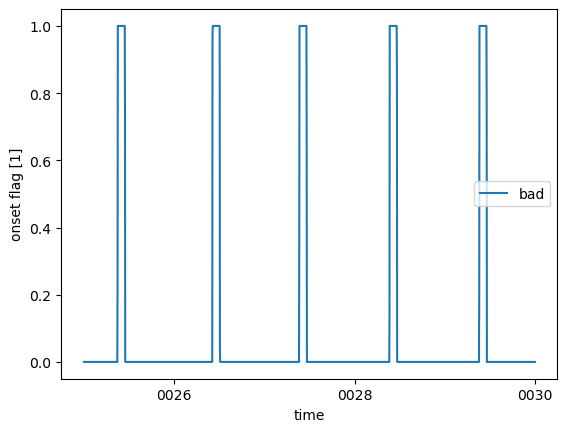

In [4]:
ds4 = xr.open_mfdataset(get_ncfiles('20240304_5', range(25,30)))
ds4['ONSET_FLAG'][:, 11].plot(label = 'bad')
plt.legend()
ds3.close()

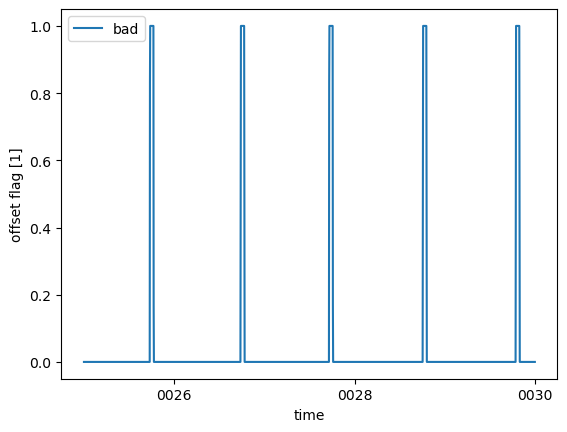

In [7]:
ds4 = xr.open_mfdataset(get_ncfiles('20240304_5', range(25,30)))
ds4['OFFSET_FLAG'][:, 11].plot(label = 'bad')
plt.legend()
ds3.close()

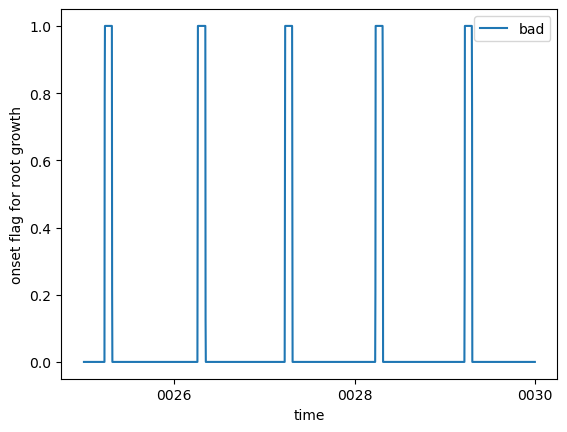

In [8]:
ds4 = xr.open_mfdataset(get_ncfiles('20240304_5', range(25,30)))
ds4['ONSET_FLAG_ROOT'][:, 11].plot(label = 'bad')
plt.legend()
ds3.close()

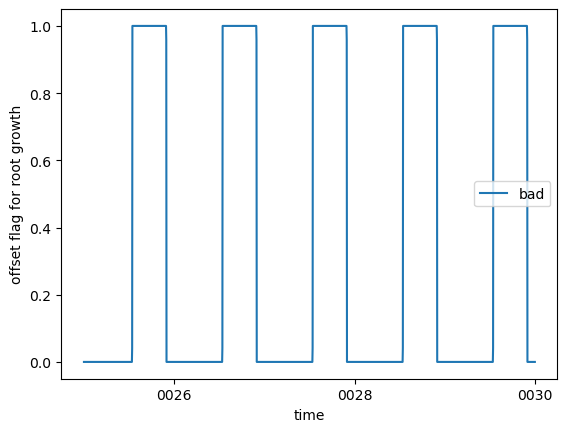

In [9]:
ds4 = xr.open_mfdataset(get_ncfiles('20240304_5', range(25,30)))
ds4['OFFSET_FLAG_ROOT'][:, 11].plot(label = 'bad')
plt.legend()
ds3.close()